In [ ]:
#1. Karpathy'nin İngilizce names.txt dosyasıyla başla, Türkçe veri görev 5'te gelecek. Bigram'ları önce Python dictionary ile, sonra 27x27 torch tensor'da say.
#Tabloyu videodaki gibi görselleştir.

In [3]:
words = open('names.txt', 'r').read().splitlines()

In [70]:
b = {}
for i in words:
    chs = ['.'] + list(i) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0)+1

In [71]:
sum(b.values()) #Thats how much biagram we've counted. Needs double check

228146

In [72]:
sum(len(w) + 1 for w in words) #That should give biagram number in real also cuz for example a word which has 3 characters creates 4 biagram,
                                #both matches so we are ok.

228146

In [73]:
import torch

In [90]:
N = torch.zeros(27,27, dtype=torch.int32) 

In [91]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [92]:
for w in words:
    chs = ["."] + list(w) + ["."] 
    for ch1, ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2,] += 1 #missed = first and cost about 15 min :(

In [93]:
N.sum() #that is also correct

tensor(228146)

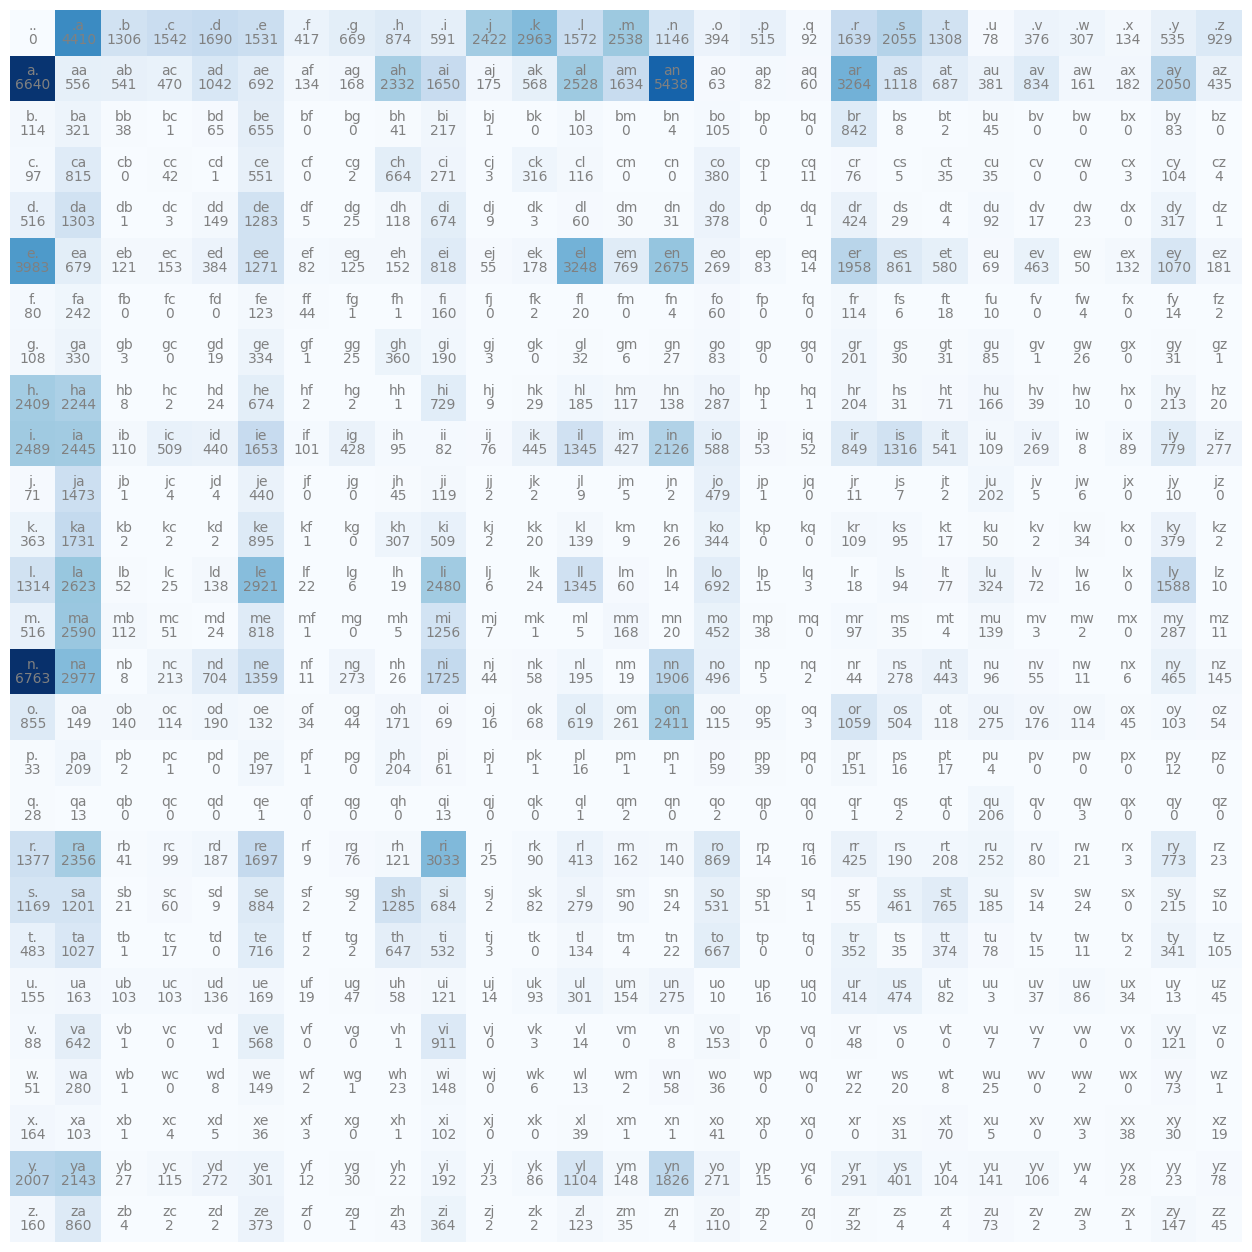

In [94]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

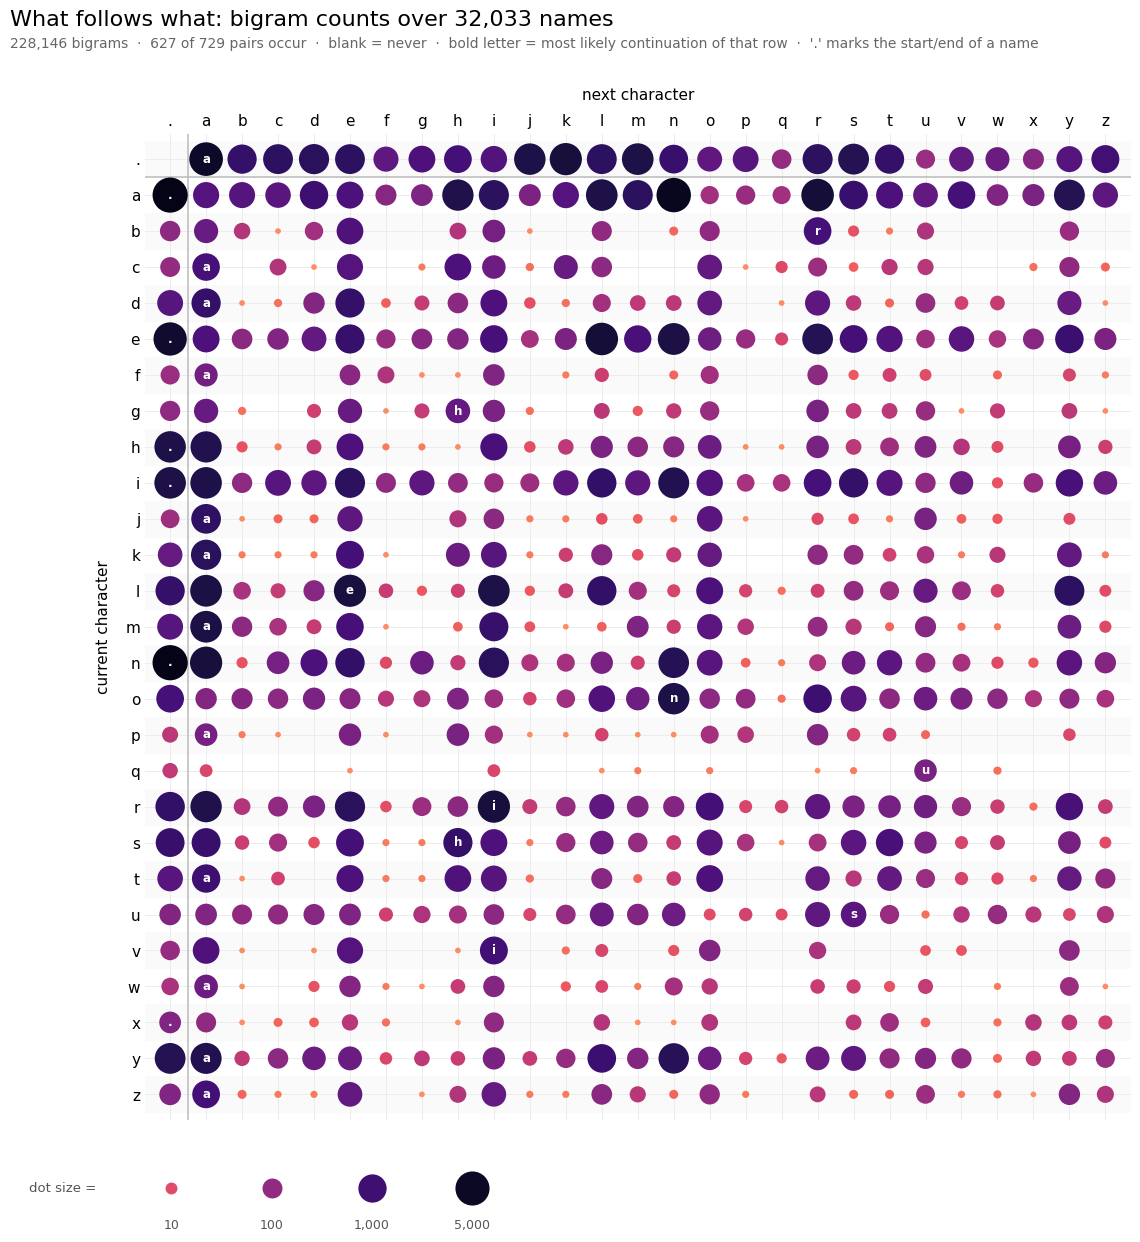

In [95]:
#additional ai-assisted visulization.
import numpy as np
import matplotlib.pyplot as plt

Nn = N.numpy().astype(float)
labels = [itos[i] for i in range(27)]
cmap = plt.get_cmap("magma_r")
vmax = Nn.max()

def size_of(v):  return (2.5 + 25.0 * np.log1p(v) / np.log1p(vmax)) ** 2 * 0.85
def color_of(v): return cmap(0.18 + 0.78 * np.log1p(v) / np.log1p(vmax))

plt.rcParams.update({"font.size": 10})
fig, ax = plt.subplots(figsize=(13.5, 12.8))
fig.subplots_adjust(left=.065, right=.995, top=.875, bottom=.105)

for k in range(0, 27, 2):
    ax.axhspan(k - .5, k + .5, color="#fafafa", zorder=0)
ax.grid(color="#ececec", linewidth=.7, zorder=1)
ax.axhline(.5, color="#bbbbbb", linewidth=1.1, zorder=2)   # separate the '.' row
ax.axvline(.5, color="#bbbbbb", linewidth=1.1, zorder=2)   # and the '.' column

ii, jj = np.meshgrid(np.arange(27), np.arange(27), indexing="ij")
m = Nn > 0
ax.scatter(jj[m], ii[m], s=size_of(Nn[m]), c=color_of(Nn[m]), zorder=3, linewidths=0)

for i in range(27):                                        # most likely continuation per row
    j = int(Nn[i].argmax())
    ax.text(j, i, itos[j], ha="center", va="center", fontsize=8.5,
            color="white", zorder=4, fontweight="bold")

ax.set_xlim(-.7, 26.7); ax.set_ylim(26.7, -.7); ax.set_aspect("equal")
ax.set_xticks(range(27), labels, fontsize=11)
ax.set_yticks(range(27), labels, fontsize=11)
ax.set_xlabel("next character", labelpad=10, fontsize=11)
ax.set_ylabel("current character", labelpad=10, fontsize=11)
ax.tick_params(length=0)
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
for s in ax.spines.values(): s.set_visible(False)

axl = fig.add_axes([.075, .018, .42, .062]); axl.set_axis_off()
axl.set_xlim(-1.6, 8); axl.set_ylim(-.6, .6)
axl.text(-1.5, .05, "dot size =", ha="left", va="center", fontsize=9.5, color="#555")
for k, v in enumerate([10, 100, 1000, 5000]):
    axl.scatter([k * 1.7 + .9], [.05], s=size_of(v), c=[color_of(v)], linewidths=0)
    axl.text(k * 1.7 + .9, -.42, f"{v:,}", ha="center", va="top", fontsize=9, color="#555")

fig.suptitle("What follows what: bigram counts over 32,033 names",
             x=.065, ha="left", fontsize=16, y=.972)
fig.text(.065, .942, f"{int(Nn.sum()):,} bigrams  ·  {int((Nn>0).sum())} of 729 pairs occur  "
                     f"·  blank = never  ·  bold letter = most likely continuation of that row  "
                     f"·  '.' marks the start/end of a name",
         fontsize=10, color="#666");

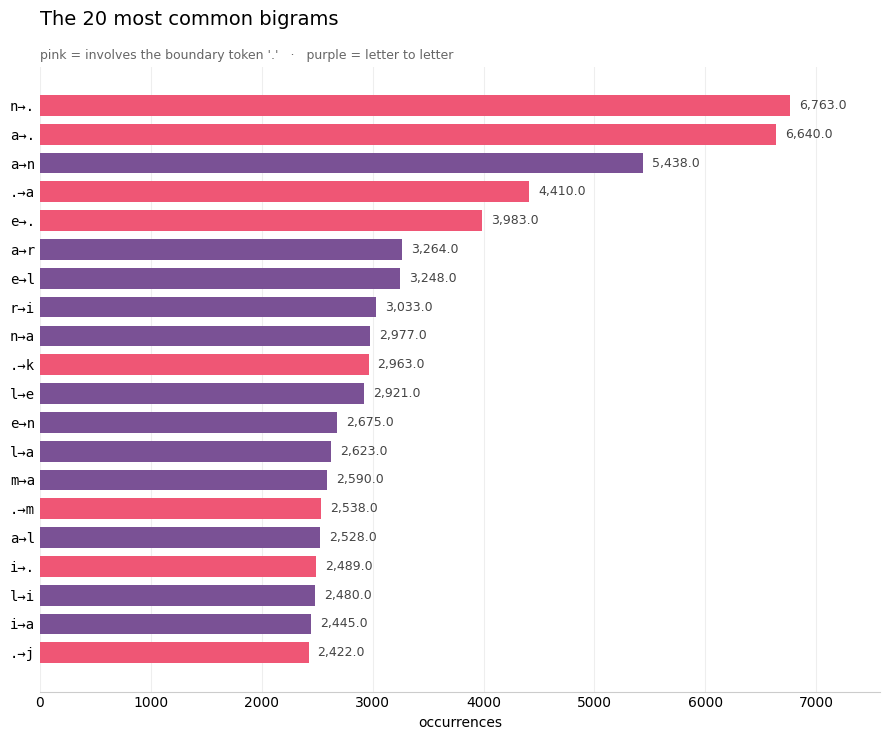

In [96]:
#additional ai-assisted visulization.
pairs = [(itos[i]+itos[j], Nn[i,j]) for i in range(27) for j in range(27) if Nn[i,j] > 0]
pairs.sort(key=lambda t: t[1], reverse=True)
top = pairs[:20][::-1]
names, vals = [p[0] for p in top], [p[1] for p in top]
colors = ["#ef5675" if "." in n else "#7a5195" for n in names]

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.barh(range(20), vals, color=colors, height=.72)
ax.set_yticks(range(20), [f"{n[0]}→{n[1]}" for n in names], fontfamily="monospace")
for k, v in enumerate(vals):
    ax.text(v + max(vals)*.012, k, f"{v:,}", va="center", fontsize=9, color="#444")
ax.set_xlim(0, max(vals)*1.12)
ax.set_xlabel("occurrences")
ax.tick_params(length=0)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_axisbelow(True); ax.xaxis.grid(True, color="#eeeeee")
ax.set_title("The 20 most common bigrams", loc="left", fontsize=14, pad=30)
ax.text(0, 1.012, "pink = involves the boundary token '.'   ·   purple = letter to letter",
        transform=ax.transAxes, fontsize=9, color="#666")
fig.tight_layout();